# Module 04: pandas Intro

**By the end you will be able to:**
- build a **DataFrame** by hand and load one from a file
- inspect it, and count the values in a column
- select columns and rows, and filter by a condition
- add a new column, summarize with groupby, and make quick plots

pandas is where this course lives. A **DataFrame** is just a table: rows and named columns. If Module 02's dictionary made sense, you already know the shape of it.

## 1. Load a table from a file
We read the tips dataset. `df` is the conventional name for a DataFrame.

In [49]:
import pandas as pd                 # standard nickname

df = pd.read_csv('../data/tips.csv')  # read the CSV into a DataFrame
df.head()                             # show the first 5 rows

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4


## 2. Build a DataFrame by hand (from a dictionary)
You don't always read a file. You can make a DataFrame directly from a dictionary, where **each key becomes a column name** and each list becomes that column's values. This shows what a DataFrame really is: a dict of columns (remember Module 02).

In [50]:
# keys -> column names, lists -> column values
students = pd.DataFrame({
    "name":  ["Amir", "Bella", "Chen"],   # the "name" column
    "score": [88, 92, 70],                # the "score" column
    "major": ["IS", "CS", "IS"]           # the "major" column
})
students

,name,score,major
0,Amir,88,IS
1,Bella,92,CS
2,Chen,70,IS


## 3. Know your table first
Always look before you work. These tell you size, column types, and a quick numeric summary.

In [51]:
print(df.shape)      # (rows, columns) -> (244, 6)
print(df.columns)    # the column names
df.info()            # each column's type and non-missing count

(244, 6)
Index(['total_bill', 'tip', 'smoker', 'day', 'time', 'size'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   smoker      244 non-null    str    
 3   day         244 non-null    str    
 4   time        244 non-null    str    
 5   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 11.6 KB


In [52]:
df.describe()        # count, mean, min, max, quartiles for numeric columns

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## 4. Select a column
Use square brackets with the column name. One column is called a **Series**.

In [53]:
df['tip']            # just the tip column (a Series)

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64

In [54]:
df['tip'].mean()     # a column acts like a NumPy array: it has .mean(), .sum(), ...

# select several columns at once with a LIST of names (note the double brackets)
df[['total_bill', 'tip']].head()

,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61


## 5. Count the values in a column
For a categorical column (labels, not numbers), `value_counts()` tallies how many rows fall in each category, sorted most to least. This is the categorical counterpart of `.mean()`.

In [55]:
df['day'].value_counts()     # how many visits on each day?

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [56]:
df['day'].value_counts(normalize=True)   # as proportions (fractions of the whole)

day
Sat     0.356557
Sun     0.311475
Thur    0.254098
Fri     0.077869
Name: proportion, dtype: float64

## 6. Select rows by position with iloc
`iloc` = "integer location". It picks rows by their position number (starting at 0).

In [57]:
df.iloc[0]       # the first row (position 0)

total_bill     16.99
tip             1.01
smoker            No
day              Sun
time          Dinner
size               2
Name: 0, dtype: object

In [58]:
df.iloc[0:3]     # the first three rows (positions 0, 1, 2)

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3


## 7. iloc selects by POSITION; loc selects by LABEL (the row's index value)


In [59]:
df.loc[0, 'tip']     # one cell: row with index label 0, column 'tip' # row label 0, column label 'tip'


np.float64(1.01)

In [60]:
df.loc[0:3, 'tip']   # label slice is INCLUSIVE of 3 -> rows 0,1,2,3 (iloc would stop at 2)  # row labels 0..3, column 'tip'   


0    1.01
1    1.66
2    3.50
3    3.31
Name: tip, dtype: float64

In [61]:
df.loc[0, ['tip','day']]  # row label 0, two columns by name

tip    1.01
day     Sun
Name: 0, dtype: object

## 8. Filter rows by a condition (the workhorse)
The single most used pandas move. A condition makes a True/False Series, and the DataFrame keeps only the True rows.

In [62]:
# keep only the rows where the tip was more than $5
df[df['tip'] > 5].head()

,total_bill,tip,smoker,day,time,size
23,39.42,7.58,No,Sat,Dinner,4
44,30.40,5.60,No,Sun,Dinner,4
47,32.40,6.00,No,Sun,Dinner,4
52,34.81,5.20,No,Sun,Dinner,4
59,48.27,6.73,No,Sat,Dinner,4


In [63]:
# combine conditions with & (and) / | (or); wrap each one in parentheses
df[(df['total_bill'] > 40) & (df['size'] >= 4)]

,total_bill,tip,smoker,day,time,size
59,48.27,6.73,No,Sat,Dinner,4
95,40.17,4.73,Yes,Fri,Dinner,4
142,41.19,5.00,No,Thur,Lunch,5
156,48.17,5.00,No,Sun,Dinner,6
197,43.11,5.00,Yes,Thur,Lunch,4
212,48.33,9.00,No,Sat,Dinner,4


## 9. Add a new column
Assign to a column name that doesn't exist yet, and pandas creates it.

In [64]:
# tip as a percent of the bill, computed from two existing columns
df['tip_percent'] = df['tip'] / df['total_bill'] * 100   # whole-column math
df[['total_bill', 'tip', 'tip_percent']].head()

,total_bill,tip,tip_percent
0,16.99,1.01,5.944673
1,10.34,1.66,16.054159
2,21.01,3.50,16.658734
3,23.68,3.31,13.978041
4,24.59,3.61,14.680765


## 10. Group and summarize
`groupby` splits rows into groups and summarizes each. Answers "what is the average X per category?"

In [65]:
# average tip percent for each day
df.groupby('day')['tip_percent'].mean()

day
Fri     16.991303
Sat     15.315172
Sun     16.689729
Thur    16.127563
Name: tip_percent, dtype: float64

## 11. Quick plots straight from pandas
pandas can chart a column directly, no extra setup. Handy for a fast look while exploring.

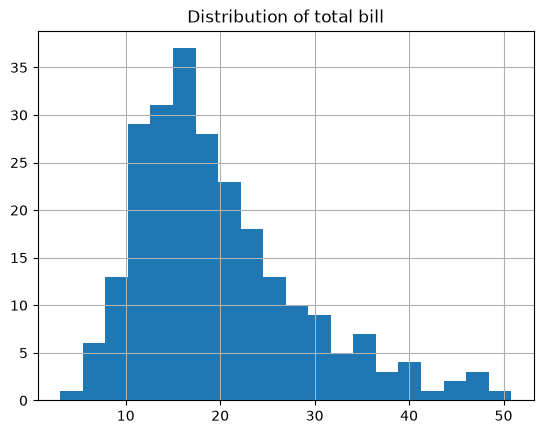

In [66]:
import matplotlib.pyplot as plt     # pandas uses matplotlib underneath

df['total_bill'].hist(bins=20)        # histogram of one numeric column
plt.title('Distribution of total bill')
plt.show()

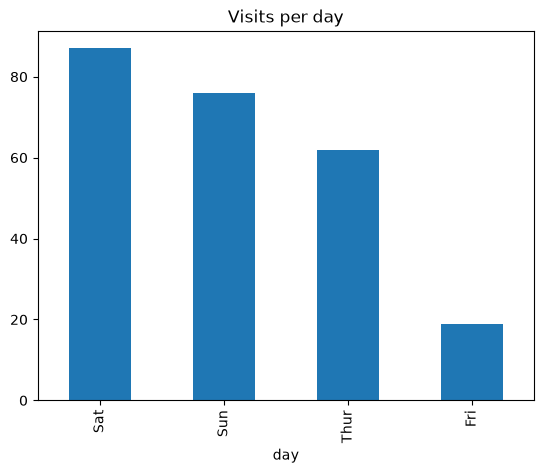

In [67]:
# a bar chart of the category counts from step 5
df['day'].value_counts().plot(kind='bar')
plt.title('Visits per day')
plt.show()

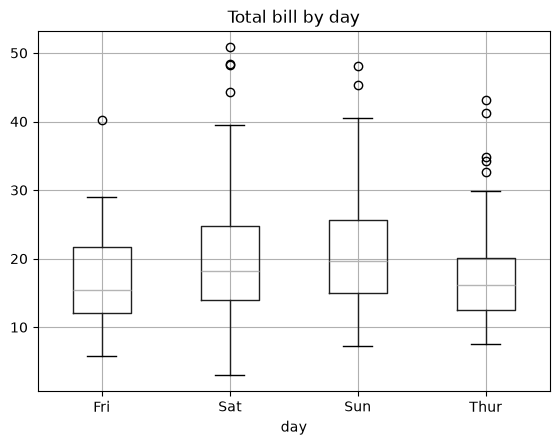

In [68]:
# a boxplot of a numeric column split by a category
df.boxplot(column='total_bill', by='day')
plt.title('Total bill by day')
plt.suptitle('')          # removes the automatic extra title pandas adds
plt.show()

## Recap
You can **build** a DataFrame from a dict or **load** one from a file; inspect it (`shape`, `info`, `describe`); count categories (`value_counts`); select columns and rows; filter by a condition; add computed columns; summarize with `groupby`; and make quick plots (`.hist`, `.plot(kind='bar')`, `.boxplot`). That is the core loop of nearly every analysis.

## Your challenge
In `practice.ipynb`: build a small DataFrame from a dict, then on the tips data count the visits by time and make a bar chart of them.